# EDA based on Heart Disease

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats


In [2]:
df=pd.read_csv('heart.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [3]:
df.shape

(1025, 14)

In [4]:
df.dtypes

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

In [5]:
print(df.columns.tolist())

['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


In [6]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB
None


Before performing exploratory data analysis,We checked the dataset for missing values.

In [7]:
#checking for null values
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

The result showed zero missing values across all 14 variables, so no missing-value treatment was required.

In [8]:
#checking duplicates
print("\n The no.of duplicate rows:",df.duplicated().sum())


 The no.of duplicate rows: 723


In [9]:
print("Number of unique rows:", df.drop_duplicates().shape[0])

Number of unique rows: 302


In [10]:
#removing duplicates
df_clean=df.drop_duplicates().copy()
df_clean.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [11]:
print(df_clean.shape)

(302, 14)


A major data-cleaning step was duplicate detection. Out of 1,025 records, 723 were duplicate rows. After removing these duplicates, the dataset contained 302 unique patient records. This cleaned dataset was then used for further analysis.

In [12]:
df_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
age,302.0,54.420530,9.047970,29.0,48.00,55.5,61.00,77.0
sex,302.0,0.682119,0.466426,0.0,0.00,1.0,1.00,1.0
cp,302.0,0.963576,1.032044,0.0,0.00,1.0,2.00,3.0
trestbps,302.0,131.602649,17.563394,94.0,120.00,130.0,140.00,200.0
chol,302.0,246.500000,51.753489,126.0,211.00,240.5,274.75,564.0
fbs,302.0,0.149007,0.356686,0.0,0.00,0.0,0.00,1.0
restecg,302.0,0.526490,0.526027,0.0,0.00,1.0,1.00,2.0
thalach,302.0,149.569536,22.903527,71.0,133.25,152.5,166.00,202.0
exang,302.0,0.327815,0.470196,0.0,0.00,0.0,1.00,1.0
oldpeak,302.0,1.043046,1.161452,0.0,0.00,0.8,1.60,6.2


The descriptive statistics show that the average age of patients is around 54 years. The average resting blood pressure is approximately 132, while the average cholesterol level is around 247. The average maximum heart rate is approximately 150 beats per minute.

In [13]:
percenage_sex=df_clean['sex'].value_counts(normalize=True)*100
print(percenage)

NameError: name 'percenage' is not defined

In [ ]:
percentage_exang=df_clean['exang'].value_counts(normalize=True)*100
print(percentage_exang)

exang
0    67.218543
1    32.781457
Name: proportion, dtype: float64


In [ ]:
percentage_target=df_clean['target'].value_counts(normalize=True)*100
print(percentage_target)

target
1    54.304636
0    45.695364
Name: proportion, dtype: float64


The average age of patients is 54.42 years, with a mean cholesterol level of 246.5 mg/dL and a mean resting blood pressure of 131.6 mmHg.
The average maximum heart rate achieved is 149.6 bpm.
Approximately 68% of patients are male, 33% experienced exercise-induced angina(chest pain), and 54% have heart disease.

In [ ]:
#Target variable analysis
df_clean['target'].value_counts()

target
1    164
0    138
Name: count, dtype: int64

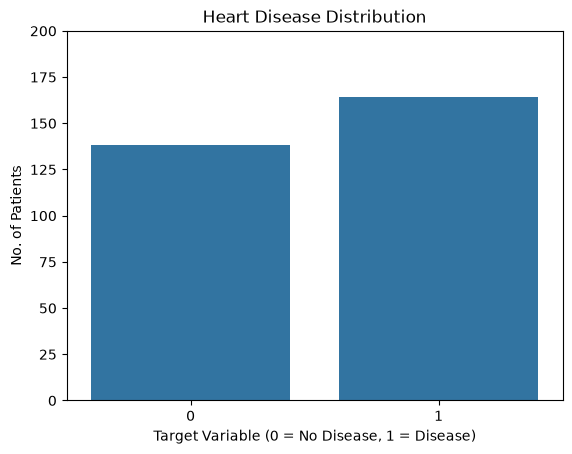

In [ ]:
# 1.Bar Chart — Heart Disease Outcome

sns.countplot(data=df_clean, x='target')
plt.title('Heart Disease Distribution')
plt.xlabel('Target Variable (0 = No Disease, 1 = Disease)')
plt.ylabel('No. of Patients')

plt.ylim(0, 200)
plt.show()

The target variable represents whether a patient has heart disease. After cleaning, 164 patients were classified as having heart disease, while 138 were classified as not having heart disease. The distribution is relatively balanced, although the disease group is slightly larger.

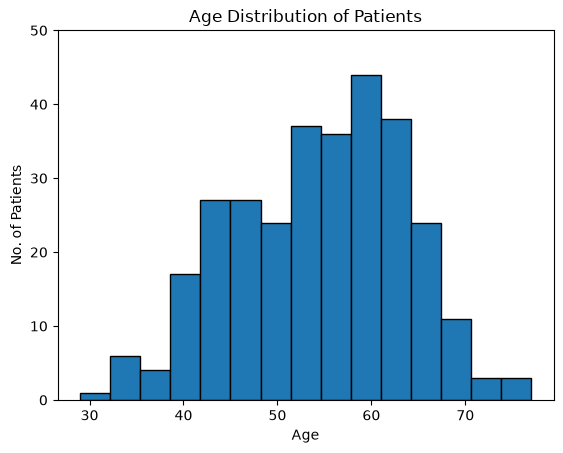

In [ ]:
# 2. Histogram — Age Distribution

plt.hist(df_clean['age'], bins=15, edgecolor='black')
plt.title('Age Distribution of Patients')
plt.xlabel('Age')
plt.ylabel('No. of Patients')
plt.ylim(0, 50)

plt.show()

The age histogram shows that the dataset contains patients mainly in the middle-aged and older age groups. The overall age range is 29 to 77 years, with an average age of approximately 54 years.
Most patients are middle-aged or older, making age an important variable to investigate in relation to heart disease.

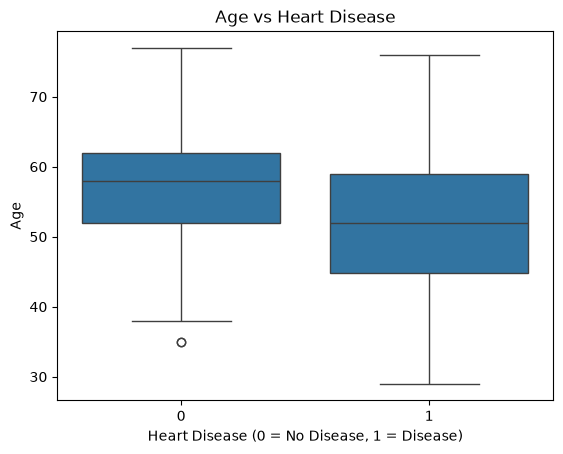

In [ ]:
# 3. Boxplot

sns.boxplot(data=df_clean, x='target', y='age')

plt.title('Age vs Heart Disease')
plt.xlabel('Heart Disease (0 = No Disease, 1 = Disease)')
plt.ylabel('Age')
plt.show()

This boxplot compares the age distribution between the two target groups. By comparing the median and spread of the two groups, we can observe whether patients with heart disease tend to be older or younger than patients without disease.

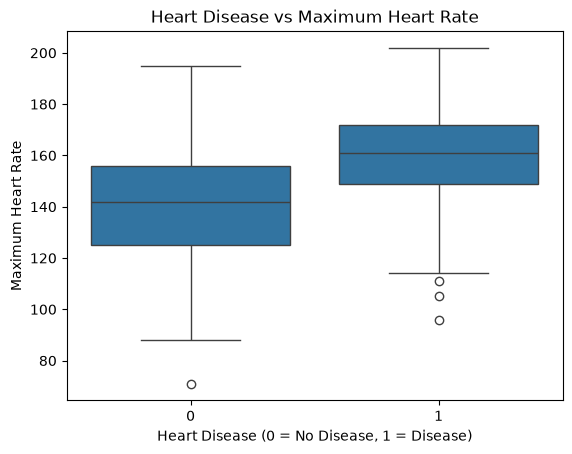

In [ ]:
sns.boxplot(data=df_clean, x='target', y='thalach')

plt.title('Heart Disease vs Maximum Heart Rate')
plt.xlabel('Heart Disease (0 = No Disease, 1 = Disease)')
plt.ylabel('Maximum Heart Rate')

plt.show()

This boxplot compares the maximum heart rate achieved by patients with and without heart disease. The distributions show that maximum heart rate differs between the two groups, We can see that in above box plot Heart Disease people has higher median max hert rate(~160) and wider spread compared to No Heart Disease people has low median(~142) with a few outliers. 
This suggests max heart rate is potentially useful feature for classifying between the two classes in this dataset.

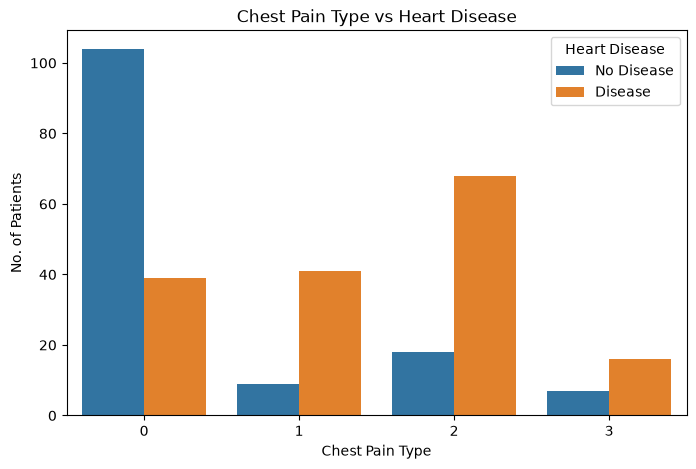

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df_clean, x='cp', hue='target')
plt.title('Chest Pain Type vs Heart Disease')
plt.xlabel('Chest Pain Type')
plt.ylabel('No. of Patients')
plt.legend(title='Heart Disease', labels=['No Disease', 'Disease'])
plt.show()

This graph shows the relationship between chest pain and heart disease. It compares patients with and without heart disease for each type of chest pain. We can see which chest pain types are more common in heart-disease patients.

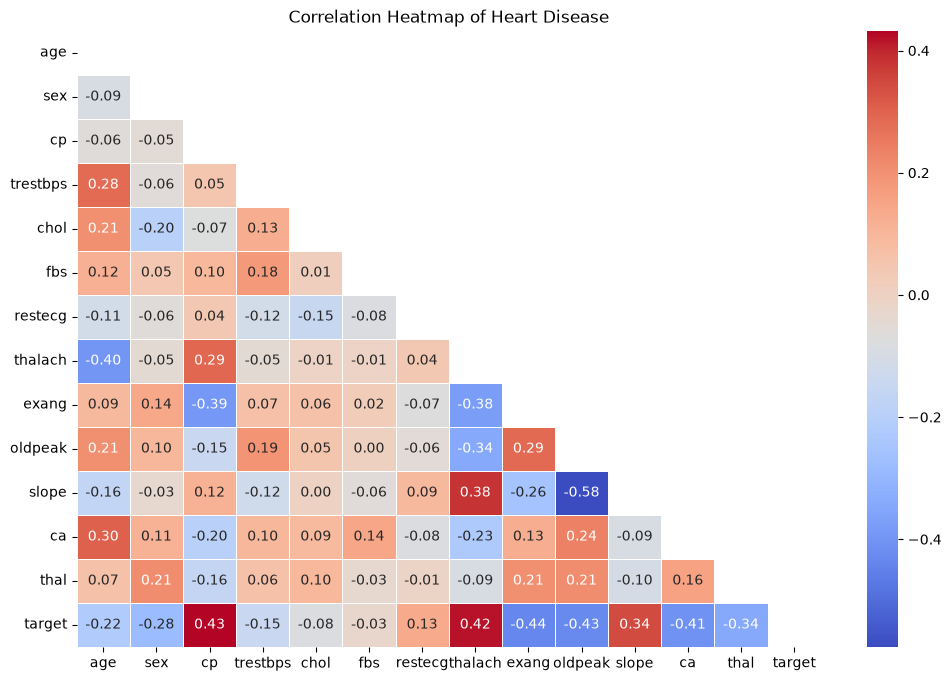

In [ ]:
#5.Correlation Heatmap

plt.figure(figsize=(12, 8))

corr_matrix = df_clean.corr(numeric_only=True)

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5,mask=np.triu(corr_matrix))

plt.title('Correlation Heatmap of Heart Disease')

plt.show()

The heatmap helps identify potentially important relationships and possible multicollinearity between features, but correlation alone does not establish a causal relationship.

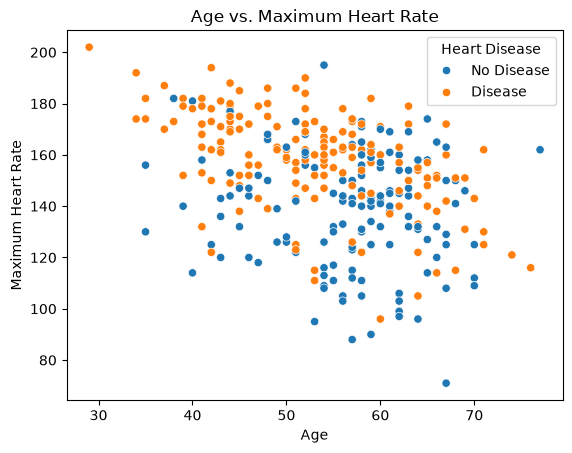

In [ ]:
#6. Scatter Plot — Age vs Maximum Heart Rate

sns.scatterplot(data=df_clean, x='age', y='thalach', hue=df_clean['target'].map({0: 'No Disease', 1: 'Disease'}))

plt.title('Age vs. Maximum Heart Rate')
plt.xlabel('Age')
plt.ylabel('Maximum Heart Rate')

plt.legend(title='Heart Disease', )
plt.show()

The scatter plot helps us visualize how maximum heart rate changes with age and whether the pattern differs between patients with and without heart disease. Generally, maximum heart rate tends to vary with age, and the target-based grouping allows us to observe differences between the two patient groups.